# Native SSA high-return / low-drawdown strategy tutorial

- `GBPJPY`: FX, 2x notional cap, long/short, 8.41% total return, 92.86% trade win rate, -0.95% maximum drawdown in the search replay.
- `SOLUSDT`: crypto spot, long-only, 38.87% total return, 54.37% trade win rate, -4.42% maximum drawdown in the search replay.

The strategy is named **SSA strategy** throughout the plots. It uses DeTime's SSA decomposition as the fast and slow trend estimator; it does not use a separate oscillator-baseline signal here.

## Strategy logic

The SSA strategy is a decomposition version of a dual-trend mean-reversion system.

1. Convert close prices to log prices.
2. On a trailing training window only, compute a fast SSA trend and a slow SSA trend.
3. Convert `fast SSA trend - slow SSA trend` to basis points. `1 bps = 0.01%`, so `100 bps = 1%`.
4. In reversion mode, enter long when the fast SSA trend is far enough below the slow SSA trend and turns upward.
5. Enter short when the fast SSA trend is far enough above the slow SSA trend and turns downward, if the configuration allows shorting.
6. Exit when the spread mean-reverts or the fast SSA slope turns against the position.
7. Signals are observed after bar `t`; orders fill at the next bar's open.

All trend features are causal walk-forward values. The code only emits the last SSA trend value from each trailing window, then forward-fills it until the next recomputation point.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from io import BytesIO
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display, Image
except ImportError:
    Image = None
    def display(obj):
        print(obj)


def display_png_figure(fig, *, dpi: int = 160) -> None:
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    buffer.seek(0)
    if Image is not None:
        display(Image(data=buffer.getvalue()))
    else:
        print(fig)

PROJECT_DIR = Path.cwd().resolve()

from detime import DecompositionConfig, decompose, native_capabilities, native_extension_available

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.style.use("seaborn-v0_8-whitegrid")

print("working directory:", PROJECT_DIR)
print("native SSA available:", native_extension_available())
print("native capabilities:", native_capabilities() if native_extension_available() else {})

repository root: /rds/projects/s/spillf-systems-mechanobiology-health-disease/Zipeng/Detime/DeTime-main
native SSA available: True
native capabilities: {'ssa_decompose': True, 'std_decompose': True, 'gabor_stft_rfft': False, 'gabor_istft_rfft': False, 'gabor_cluster_decompose': False}


In [2]:
SEARCH_REPLAY_METRICS = pd.DataFrame(
    [
        {
            "asset_class": "fx",
            "symbol": "GBPJPY",
            "total_return": 0.084119,
            "trade_win_rate": 0.928571,
            "max_drawdown": -0.009466,
            "profit_factor": 22.104442,
            "round_trips": 14,
            "sharpe": 2.330493,
            "source": "dukascopy",
            "bar_size": "3m",
            "csv_path": "examples/quant_trading/data/intraday_crypto_fx/dukascopy/dukascopy_GBPJPY_3m_2025-06-04_2026-06-04.csv",
        },
        {
            "asset_class": "crypto",
            "symbol": "SOLUSDT",
            "total_return": 0.388689,
            "trade_win_rate": 0.543689,
            "max_drawdown": -0.044184,
            "profit_factor": 2.053341,
            "round_trips": 103,
            "sharpe": 2.839898,
            "source": "binance",
            "bar_size": "3m",
            "csv_path": "examples/quant_trading/data/intraday_crypto_fx/binance/binance_SOLUSDT_3m_2025-06-04_2026-06-04.csv",
        },
    ]
)

display(
    SEARCH_REPLAY_METRICS.assign(
        total_return=lambda x: (x["total_return"] * 100).round(2),
        trade_win_rate=lambda x: (x["trade_win_rate"] * 100).round(2),
        max_drawdown=lambda x: (x["max_drawdown"] * 100).round(2),
    ).rename(
        columns={
            "total_return": "total_return_%",
            "trade_win_rate": "trade_win_rate_%",
            "max_drawdown": "max_drawdown_%",
        }
    )
)

,asset_class,symbol,total_return_%,trade_win_rate_%,max_drawdown_%,profit_factor,round_trips,sharpe,source,bar_size,csv_path
0,fx,GBPJPY,8.41,92.86,-0.95,22.104442,14,2.330493,dukascopy,3m,examples/quant_trading/data/intraday_crypto_fx...
1,crypto,SOLUSDT,38.87,54.37,-4.42,2.053341,103,2.839898,binance,3m,examples/quant_trading/data/intraday_crypto_fx...


In [3]:
@dataclass(frozen=True)
class SSAFeatureSpec:
    fast_period: int
    slow_period: int
    train_mult: int
    step: int
    fast_rank: int = 6
    slow_rank: int = 6
    speed_mode: str = "fast"

    @property
    def fast_window(self) -> int:
        return int(max(self.fast_period * 2, 8))

    @property
    def slow_window(self) -> int:
        return int(max(self.slow_period * 2, 12))

    @property
    def train_window(self) -> int:
        return int(max(self.slow_period * self.train_mult, self.slow_window + 20, 80))


@dataclass(frozen=True)
class SSATradeSpec:
    feature: SSAFeatureSpec
    strategy_mode: str = "trend_reversion"
    entry_spread_bps: float = 5.0
    exit_spread_bps: float = 0.0
    min_fast_slope_bps: float = 0.5
    require_slow_slope: bool = True
    min_slow_slope_bps: float = 0.0
    allow_short: bool = False
    initial_cash: float = 10_000.0
    trade_notional: float = 10_000.0
    max_position_notional: float = 10_000.0
    fee_bps: float = 2.0
    slippage_bps: float = 1.0

    @property
    def name(self) -> str:
        return (
            f"SSA_strategy_f{self.feature.fast_period}_s{self.feature.slow_period}"
            f"_tw{self.feature.train_window}_st{self.feature.step}"
            f"_entry{self.entry_spread_bps:g}_exit{self.exit_spread_bps:g}"
        ).replace(".", "p")


SELECTED_SPECS: dict[str, SSATradeSpec] = {
    "GBPJPY": SSATradeSpec(
        feature=SSAFeatureSpec(fast_period=24, slow_period=96, train_mult=6, step=32, fast_rank=6, slow_rank=6),
        entry_spread_bps=5.0,
        exit_spread_bps=2.5,
        min_fast_slope_bps=0.5,
        require_slow_slope=True,
        allow_short=True,
        trade_notional=20_000.0,
        max_position_notional=20_000.0,
        fee_bps=0.35,
        slippage_bps=0.5,
    ),
    "SOLUSDT": SSATradeSpec(
        feature=SSAFeatureSpec(fast_period=24, slow_period=192, train_mult=6, step=16, fast_rank=6, slow_rank=6),
        entry_spread_bps=75.0,
        exit_spread_bps=20.0,
        min_fast_slope_bps=1.5,
        require_slow_slope=True,
        allow_short=False,
        trade_notional=10_000.0,
        max_position_notional=10_000.0,
        fee_bps=2.0,
        slippage_bps=1.0,
    ),
}

pd.DataFrame(
    [
        {
            "symbol": symbol,
            "fast_ssa_period": spec.feature.fast_period,
            "slow_ssa_period": spec.feature.slow_period,
            "train_window": spec.feature.train_window,
            "step": spec.feature.step,
            "entry_bps": spec.entry_spread_bps,
            "exit_bps": spec.exit_spread_bps,
            "min_fast_slope_bps": spec.min_fast_slope_bps,
            "allow_short": spec.allow_short,
            "trade_notional": spec.trade_notional,
            "max_position_notional": spec.max_position_notional,
            "fee_bps": spec.fee_bps,
            "slippage_bps": spec.slippage_bps,
        }
        for symbol, spec in SELECTED_SPECS.items()
    ]
)

,symbol,fast_ssa_period,slow_ssa_period,train_window,step,entry_bps,exit_bps,min_fast_slope_bps,allow_short,trade_notional,max_position_notional,fee_bps,slippage_bps
0,GBPJPY,24,96,576,32,5.0,2.5,0.5,True,20000.0,20000.0,0.35,0.5
1,SOLUSDT,24,192,1152,16,75.0,20.0,1.5,False,10000.0,10000.0,2.00,1.0


In [4]:
DATA_ROOT = PROJECT_DIR / "examples" / "quant_trading" / "data" / "intraday_crypto_fx"
MANIFEST_PATHS = [
    PROJECT_DIR / "examples" / "quant_trading" / "reports" / "intraday_fx_3m_data" / "intraday_download_manifest.csv",
    PROJECT_DIR / "examples" / "quant_trading" / "reports" / "intraday_crypto_3m_data" / "intraday_download_manifest.csv",
]


def _as_repo_path(path: str | Path) -> Path:
    p = Path(path)
    return p if p.is_absolute() else PROJECT_DIR / p


def find_symbol_csv(symbol: str, *, bar_size: str = "3m") -> Path:
    symbol = symbol.upper()
    for manifest_path in MANIFEST_PATHS:
        if not manifest_path.exists():
            continue
        manifest = pd.read_csv(manifest_path)
        mask = manifest.get("symbol", pd.Series(dtype=str)).astype(str).str.upper().eq(symbol)
        if "bar_size" in manifest.columns:
            mask &= manifest["bar_size"].astype(str).eq(bar_size)
        if "status" in manifest.columns:
            mask &= manifest["status"].astype(str).str.lower().eq("ok")
        hits = manifest.loc[mask]
        for raw_path in hits.get("output_path", []):
            p = _as_repo_path(raw_path)
            if p.exists():
                return p

    patterns = [f"**/*_{symbol}_{bar_size}_*.csv", f"**/*{symbol}*{bar_size}*.csv"]
    for pattern in patterns:
        for p in sorted(DATA_ROOT.glob(pattern)):
            if p.is_file():
                return p

    raise FileNotFoundError(
        f"Could not find {symbol} {bar_size} CSV. Put the downloaded file under {DATA_ROOT} "
        "or pass csv_path=... to run_selected_strategy()."
    )


def load_ohlcv_csv(path: str | Path) -> pd.DataFrame:
    p = _as_repo_path(path)
    df = pd.read_csv(p)
    date_col = next((c for c in ["Datetime", "datetime", "Date", "date", "timestamp", "Timestamp", "time", "Time"] if c in df.columns), None)
    if date_col is not None:
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce", utc=True)
        df = df.dropna(subset=[date_col]).set_index(date_col)
    else:
        df.index = pd.to_datetime(df.index, errors="coerce", utc=True)
        df = df.loc[df.index.notna()]

    rename = {}
    for col in df.columns:
        low = str(col).lower()
        if low == "open":
            rename[col] = "Open"
        elif low == "high":
            rename[col] = "High"
        elif low == "low":
            rename[col] = "Low"
        elif low == "close":
            rename[col] = "Close"
        elif low in {"volume", "basevolume", "tickvolume"}:
            rename[col] = "Volume"
    df = df.rename(columns=rename)

    if "Close" not in df.columns:
        raise ValueError(f"{p} must contain a Close column.")
    if "Open" not in df.columns:
        df["Open"] = df["Close"]
    if "High" not in df.columns:
        df["High"] = df[["Open", "Close"]].max(axis=1)
    if "Low" not in df.columns:
        df["Low"] = df[["Open", "Close"]].min(axis=1)
    if "Volume" not in df.columns:
        df["Volume"] = 0.0

    out = df[["Open", "High", "Low", "Close", "Volume"]].apply(pd.to_numeric, errors="coerce")
    out = out.sort_index().replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna(subset=["Open", "Close"])
    out = out[(out["Open"] > 0) & (out["Close"] > 0)]
    if out.empty:
        raise ValueError(f"{p} contains no positive OHLC rows.")
    return out


def infer_periods_per_year(symbol: str, *, source: str, bar_size: str) -> int:
    bars_per_day = {"1m": 1440, "3m": 480, "15m": 96}.get(bar_size, 1)
    is_fx = source.lower() == "dukascopy" or (len(symbol) == 6 and symbol.isalpha())
    return int(bars_per_day * (252 if is_fx else 365))

In [5]:
def last_ssa_trend(
    values: np.ndarray,
    *,
    period: int,
    window: int,
    rank: int,
    backend: str = "auto",
    speed_mode: str = "fast",
) -> float:
    cfg = DecompositionConfig(
        method="SSA",
        params={"window": int(window), "rank": int(rank), "primary_period": int(period)},
        backend=backend,
        speed_mode=speed_mode,
        seed=42,
    )
    result = decompose(np.asarray(values, dtype=float), cfg)
    trend = np.asarray(result.trend, dtype=float).reshape(-1)
    return float(trend[-1]) if trend.size else float("nan")


def walkforward_dual_ssa_trends(close: pd.Series, spec: SSAFeatureSpec, *, backend: str = "auto") -> pd.DataFrame:
    clean = pd.Series(close).sort_index().astype(float)
    clean = clean.replace([np.inf, -np.inf], np.nan).ffill().bfill()
    clean = clean[clean > 0].dropna()
    y = np.log(clean)

    out = pd.DataFrame(index=clean.index, columns=["fast_trend", "slow_trend"], dtype=float)
    start = int(max(spec.train_window, spec.slow_window + 2, spec.fast_window + 2))

    for end in range(start, len(y) + 1, int(spec.step)):
        window = y.iloc[max(0, end - spec.train_window) : end]
        if len(window) < start:
            continue
        values = window.to_numpy(dtype=float)
        stamp = y.index[end - 1]
        try:
            fast = last_ssa_trend(
                values,
                period=spec.fast_period,
                window=spec.fast_window,
                rank=spec.fast_rank,
                backend=backend,
                speed_mode=spec.speed_mode,
            )
            slow = last_ssa_trend(
                values,
                period=spec.slow_period,
                window=spec.slow_window,
                rank=spec.slow_rank,
                backend=backend,
                speed_mode=spec.speed_mode,
            )
        except Exception as exc:
            print(f"SSA failed at {stamp}: {exc}")
            continue
        out.loc[stamp, "fast_trend"] = fast
        out.loc[stamp, "slow_trend"] = slow

    out = out.ffill()
    out["log_close"] = y.reindex(out.index)
    out["fast_slope_bps"] = out["fast_trend"].diff(int(spec.step)).div(max(int(spec.step), 1)) * 10_000.0
    out["slow_slope_bps"] = out["slow_trend"].diff(int(spec.step)).div(max(int(spec.step), 1)) * 10_000.0
    out["spread_bps"] = (out["fast_trend"] - out["slow_trend"]) * 10_000.0
    out["fast_ssa_trend"] = np.exp(out["fast_trend"])
    out["slow_ssa_trend"] = np.exp(out["slow_trend"])
    return out

In [6]:
def dual_ssa_events(features: pd.DataFrame, spec: SSATradeSpec) -> dict[str, pd.Series]:
    f = features.replace([np.inf, -np.inf], np.nan)
    spread = f["spread_bps"]
    fast_slope = f["fast_slope_bps"]
    slow_slope = f["slow_slope_bps"]
    valid = spread.notna() & fast_slope.notna() & slow_slope.notna()

    long_entries = (spread <= -spec.entry_spread_bps) & (fast_slope >= spec.min_fast_slope_bps)
    short_entries = (spread >= spec.entry_spread_bps) & (fast_slope <= -spec.min_fast_slope_bps)
    if spec.require_slow_slope:
        long_entries &= slow_slope >= spec.min_slow_slope_bps
        short_entries &= slow_slope <= -spec.min_slow_slope_bps

    long_exits = (spread >= -spec.exit_spread_bps) | (fast_slope <= -spec.min_fast_slope_bps)
    short_exits = (spread <= spec.exit_spread_bps) | (fast_slope >= spec.min_fast_slope_bps)

    if not spec.allow_short:
        short_entries = pd.Series(False, index=f.index)
        short_exits = pd.Series(False, index=f.index)

    return {
        "long_entries": (valid & long_entries).fillna(False).astype(bool),
        "long_exits": long_exits.fillna(False).astype(bool),
        "short_entries": (valid & short_entries).fillna(False).astype(bool),
        "short_exits": short_exits.fillna(False).astype(bool),
    }


def run_cash_backtest(ohlcv: pd.DataFrame, features: pd.DataFrame, spec: SSATradeSpec, *, periods_per_year: int) -> dict[str, Any]:
    data = ohlcv.sort_index().copy()
    events = dual_ssa_events(features.reindex(data.index), spec)

    cash = float(spec.initial_cash)
    position = 0.0
    avg_entry = 0.0
    entry_fee = 0.0
    entry_time = None
    entry_side = None
    pending_close = False
    pending_open_side = 0
    notional = min(float(spec.trade_notional), float(spec.max_position_notional))
    fee_rate = float(spec.fee_bps) / 10_000.0
    slip_rate = float(spec.slippage_bps) / 10_000.0

    equity_rows = []
    order_rows = []
    trade_rows = []

    for i, (stamp, row) in enumerate(data.iterrows()):
        open_px = float(row["Open"])
        close_px = float(row["Close"])

        if pending_close and position != 0.0 and np.isfinite(open_px) and open_px > 0:
            if position > 0:
                fill = open_px * (1.0 - slip_rate)
                gross = position * fill
                fee = gross * fee_rate
                cash += gross - fee
                gross_pnl = (fill - avg_entry) * position
                exit_side = "sell"
            else:
                fill = open_px * (1.0 + slip_rate)
                units = abs(position)
                gross = units * fill
                fee = gross * fee_rate
                cash -= gross + fee
                gross_pnl = (avg_entry - fill) * units
                exit_side = "cover"

            net_pnl = gross_pnl - fee - entry_fee
            order_rows.append({"timestamp": stamp, "action": exit_side, "price": fill, "units": abs(position), "fee": fee})
            trade_rows.append(
                {
                    "entry_time": entry_time,
                    "exit_time": stamp,
                    "side": entry_side,
                    "entry_price": avg_entry,
                    "exit_price": fill,
                    "units": abs(position),
                    "gross_pnl": gross_pnl,
                    "net_pnl": net_pnl,
                    "return_on_notional": net_pnl / max(notional, 1e-12),
                }
            )
            position = 0.0
            avg_entry = 0.0
            entry_fee = 0.0
            entry_time = None
            entry_side = None

        if pending_open_side != 0 and position == 0.0 and np.isfinite(open_px) and open_px > 0:
            if pending_open_side == 1:
                fill = open_px * (1.0 + slip_rate)
                units = notional / fill
                fee = notional * fee_rate
                cash -= notional + fee
                position = units
                action = "buy"
                entry_side = "long"
            elif spec.allow_short:
                fill = open_px * (1.0 - slip_rate)
                units = notional / fill
                fee = notional * fee_rate
                cash += notional - fee
                position = -units
                action = "short"
                entry_side = "short"
            else:
                fill = np.nan
                units = 0.0
                fee = 0.0
                action = "skip_short"

            if action != "skip_short":
                avg_entry = fill
                entry_fee = fee
                entry_time = stamp
                order_rows.append({"timestamp": stamp, "action": action, "price": fill, "units": units, "fee": fee})

        pending_close = False
        pending_open_side = 0

        equity = cash + position * close_px
        equity_rows.append({"timestamp": stamp, "cash": cash, "position_units": position, "close": close_px, "equity": equity})

        if i + 1 >= len(data):
            continue

        le = bool(events["long_entries"].iloc[i])
        lx = bool(events["long_exits"].iloc[i])
        se = bool(events["short_entries"].iloc[i])
        sx = bool(events["short_exits"].iloc[i])

        if position > 0:
            pending_close = lx or se
            pending_open_side = -1 if se and spec.allow_short else 0
        elif position < 0:
            pending_close = sx or le
            pending_open_side = 1 if le else 0
        else:
            pending_open_side = 1 if le else (-1 if se and spec.allow_short else 0)

    account = pd.DataFrame(equity_rows).set_index("timestamp")
    orders = pd.DataFrame(order_rows)
    trades = pd.DataFrame(trade_rows)
    stats = performance_summary(account, trades, periods_per_year=periods_per_year, initial_cash=spec.initial_cash)
    return {"account": account, "orders": orders, "trades": trades, "stats": stats, "events": events}

In [7]:
def drawdown(equity: pd.Series) -> pd.Series:
    equity = pd.Series(equity).astype(float)
    return equity / equity.cummax().replace(0, np.nan) - 1.0


def performance_summary(account: pd.DataFrame, trades: pd.DataFrame, *, periods_per_year: int, initial_cash: float) -> dict[str, float]:
    equity = account["equity"].astype(float)
    returns = equity.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    total_return = equity.iloc[-1] / initial_cash - 1.0
    years = max(len(equity) / float(periods_per_year), 1e-12)
    cagr = (equity.iloc[-1] / initial_cash) ** (1.0 / years) - 1.0 if equity.iloc[-1] > 0 else np.nan
    vol = returns.std(ddof=0) * np.sqrt(float(periods_per_year))
    sharpe = returns.mean() * float(periods_per_year) / vol if vol > 0 else np.nan
    max_dd = drawdown(equity).min()

    if trades.empty:
        trade_win_rate = np.nan
        profit_factor = np.nan
        avg_trade_net_pnl = np.nan
        round_trips = 0
    else:
        pnl = trades["net_pnl"].astype(float)
        wins = pnl[pnl > 0].sum()
        losses = -pnl[pnl < 0].sum()
        trade_win_rate = float((pnl > 0).mean())
        profit_factor = float(wins / losses) if losses > 0 else np.inf
        avg_trade_net_pnl = float(pnl.mean())
        round_trips = int(len(trades))

    return {
        "total_return": float(total_return),
        "cagr": float(cagr),
        "volatility": float(vol),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd),
        "bar_hit_rate": float((returns > 0).mean()),
        "trade_win_rate": float(trade_win_rate) if np.isfinite(trade_win_rate) else np.nan,
        "profit_factor": float(profit_factor) if np.isfinite(profit_factor) else np.inf,
        "round_trips": float(round_trips),
        "orders": float(round_trips * 2),
        "average_trade_net_pnl": float(avg_trade_net_pnl) if np.isfinite(avg_trade_net_pnl) else np.nan,
        "final_equity": float(equity.iloc[-1]),
        "net_profit": float(equity.iloc[-1] - initial_cash),
    }


def month_period_index(index: pd.Index) -> pd.PeriodIndex:
    dt_index = pd.DatetimeIndex(index)
    if dt_index.tz is not None:
        dt_index = dt_index.tz_convert(None)
    return dt_index.to_period("M")


def monthly_performance_table(account: pd.DataFrame, trades: pd.DataFrame, *, initial_cash: float) -> pd.DataFrame:
    equity = account["equity"].astype(float)
    rows = []
    previous_equity = float(initial_cash)
    trade_month = None
    if not trades.empty:
        trade_month = pd.to_datetime(trades["exit_time"], utc=True).dt.tz_convert(None).dt.to_period("M")

    for period, month_equity in equity.groupby(month_period_index(equity.index)):
        month_return = month_equity.iloc[-1] / previous_equity - 1.0
        month_dd = drawdown(month_equity).min()
        if trade_month is None:
            month_trades = trades.iloc[0:0]
        else:
            month_trades = trades.loc[trade_month == period]
        win_rate = np.nan if month_trades.empty else float((month_trades["net_pnl"] > 0).mean())
        rows.append(
            {
                "month": str(period),
                "return_%": month_return * 100.0,
                "trade_win_rate_%": win_rate * 100.0 if np.isfinite(win_rate) else np.nan,
                "max_drawdown_%": month_dd * 100.0,
                "round_trips": int(len(month_trades)),
                "end_equity": float(month_equity.iloc[-1]),
            }
        )
        previous_equity = float(month_equity.iloc[-1])
    return pd.DataFrame(rows)


def stats_frame(results: dict[str, dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for symbol, result in results.items():
        row = {"symbol": symbol}
        row.update(result["stats"])
        rows.append(row)
    out = pd.DataFrame(rows)
    percent_cols = ["total_return", "cagr", "volatility", "max_drawdown", "bar_hit_rate", "trade_win_rate"]
    for col in percent_cols:
        if col in out.columns:
            out[col] = out[col] * 100.0
    return out.rename(
        columns={
            "total_return": "total_return_%",
            "cagr": "cagr_%",
            "volatility": "volatility_%",
            "max_drawdown": "max_drawdown_%",
            "bar_hit_rate": "bar_hit_rate_%",
            "trade_win_rate": "trade_win_rate_%",
        }
    )

In [8]:
def plot_ssa_strategy_dashboard(symbol: str, ohlcv: pd.DataFrame, features: pd.DataFrame, result: dict[str, Any], *, months_in_table: int = 12) -> pd.DataFrame:
    account = result["account"]
    orders = result["orders"]
    trades = result["trades"]
    spec = SELECTED_SPECS[symbol]

    close = ohlcv["Close"].reindex(account.index)
    strategy_equity = account["equity"]
    buy_hold_equity = spec.initial_cash * close / close.dropna().iloc[0]
    strategy_dd = drawdown(strategy_equity) * 100.0
    buy_hold_dd = drawdown(buy_hold_equity) * 100.0
    monthly = monthly_performance_table(account, trades, initial_cash=spec.initial_cash)

    fig = plt.figure(figsize=(16, 11), constrained_layout=True)
    grid = fig.add_gridspec(3, 2, height_ratios=[1.25, 1.0, 0.9])
    ax_price = fig.add_subplot(grid[0, :])
    ax_equity = fig.add_subplot(grid[1, 0])
    ax_dd = fig.add_subplot(grid[1, 1])
    ax_table = fig.add_subplot(grid[2, :])

    ax_price.plot(close.index, close, label="Close", color="#263238", linewidth=1.0)
    ax_price.plot(features.index, features["fast_ssa_trend"], label="Fast SSA trend", color="#1565c0", linewidth=1.0, alpha=0.9)
    ax_price.plot(features.index, features["slow_ssa_trend"], label="Slow SSA trend", color="#8e24aa", linewidth=1.0, alpha=0.9)

    if not orders.empty:
        plotted = set()
        markers = {
            "buy": ("^", "#2e7d32", "Buy"),
            "sell": ("v", "#c62828", "Sell"),
            "short": ("v", "#ef6c00", "Short"),
            "cover": ("^", "#00695c", "Cover"),
        }
        for action, group in orders.groupby("action"):
            if action not in markers:
                continue
            marker, color, label = markers[action]
            label = label if label not in plotted else None
            ax_price.scatter(group["timestamp"], group["price"], marker=marker, s=44, color=color, edgecolor="white", linewidth=0.5, label=label, zorder=5)
            plotted.add(markers[action][2])

    ax_price.set_title(f"{symbol} SSA strategy buy/sell analysis")
    ax_price.set_ylabel("Price")
    ax_price.legend(loc="upper left", ncols=3, fontsize=9)

    ax_equity.plot(strategy_equity.index, strategy_equity, label="SSA strategy", color="#1565c0", linewidth=1.3)
    ax_equity.plot(buy_hold_equity.index, buy_hold_equity, label="Buy and hold", color="#6d4c41", linewidth=1.0, alpha=0.85)
    ax_equity.set_title("Equity comparison")
    ax_equity.set_ylabel("Equity")
    ax_equity.legend(loc="upper left", fontsize=9)

    ax_dd.plot(strategy_dd.index, strategy_dd, label="SSA strategy drawdown", color="#1565c0", linewidth=1.2)
    ax_dd.plot(buy_hold_dd.index, buy_hold_dd, label="Buy and hold drawdown", color="#6d4c41", linewidth=1.0, alpha=0.85)
    ax_dd.axhline(-20.0, color="#b71c1c", linestyle="--", linewidth=1.0, label="-20% limit")
    ax_dd.set_title("Maximum drawdown curve")
    ax_dd.set_ylabel("Drawdown %")
    ax_dd.legend(loc="lower left", fontsize=9)

    ax_table.axis("off")
    table_data = monthly.tail(months_in_table).copy()
    display_table = table_data.copy()
    for col in ["return_%", "trade_win_rate_%", "max_drawdown_%"]:
        display_table[col] = display_table[col].map(lambda x: "" if pd.isna(x) else f"{x:.2f}")
    display_table["end_equity"] = display_table["end_equity"].map(lambda x: f"{x:,.0f}")
    table = ax_table.table(
        cellText=display_table.values,
        colLabels=display_table.columns,
        loc="center",
        cellLoc="center",
        bbox=[0.0, 0.0, 1.0, 1.0],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1.0, 1.15)
    ax_table.set_title("Monthly return, win rate, maximum drawdown and trade count", pad=8)

    display_png_figure(fig)
    plt.close(fig)
    return monthly

In [9]:
def run_selected_strategy(symbol: str, *, csv_path: str | Path | None = None, backend: str = "auto", max_bars: int | None = None) -> dict[str, Any]:
    spec = SELECTED_SPECS[symbol]
    metrics_row = SEARCH_REPLAY_METRICS.loc[SEARCH_REPLAY_METRICS["symbol"].eq(symbol)].iloc[0]
    path = _as_repo_path(csv_path) if csv_path is not None else find_symbol_csv(symbol, bar_size=str(metrics_row["bar_size"]))
    ohlcv = load_ohlcv_csv(path)
    if max_bars is not None:
        ohlcv = ohlcv.tail(int(max_bars)).copy()
    periods_per_year = infer_periods_per_year(symbol, source=str(metrics_row["source"]), bar_size=str(metrics_row["bar_size"]))
    features = walkforward_dual_ssa_trends(ohlcv["Close"], spec.feature, backend=backend)
    backtest = run_cash_backtest(ohlcv, features, spec, periods_per_year=periods_per_year)
    return {"symbol": symbol, "csv_path": path, "ohlcv": ohlcv, "features": features, **backtest}

In [10]:
# For a quick notebook check, set MAX_BARS to a smaller value such as 20000.
# For the full one-year replay used by the search table, keep MAX_BARS = None.
SSA_BACKEND = "auto"
MAX_BARS = None

results = {symbol: run_selected_strategy(symbol, backend=SSA_BACKEND, max_bars=MAX_BARS) for symbol in SELECTED_SPECS}
display(stats_frame(results).round(4))

,symbol,total_return_%,cagr_%,volatility_%,sharpe,max_drawdown_%,bar_hit_rate_%,trade_win_rate_%,profit_factor,round_trips,orders,average_trade_net_pnl,final_equity,net_profit
0,GBPJPY,8.4119,5.7347,2.4052,2.3305,-0.9466,0.6878,92.8571,22.1044,14.0,28.0,60.0850,10841.1903,841.1903
1,SOLUSDT,38.8689,38.8689,11.8078,2.8399,-4.4184,1.7751,54.3689,2.0533,103.0,206.0,37.7368,13886.8916,3886.8916


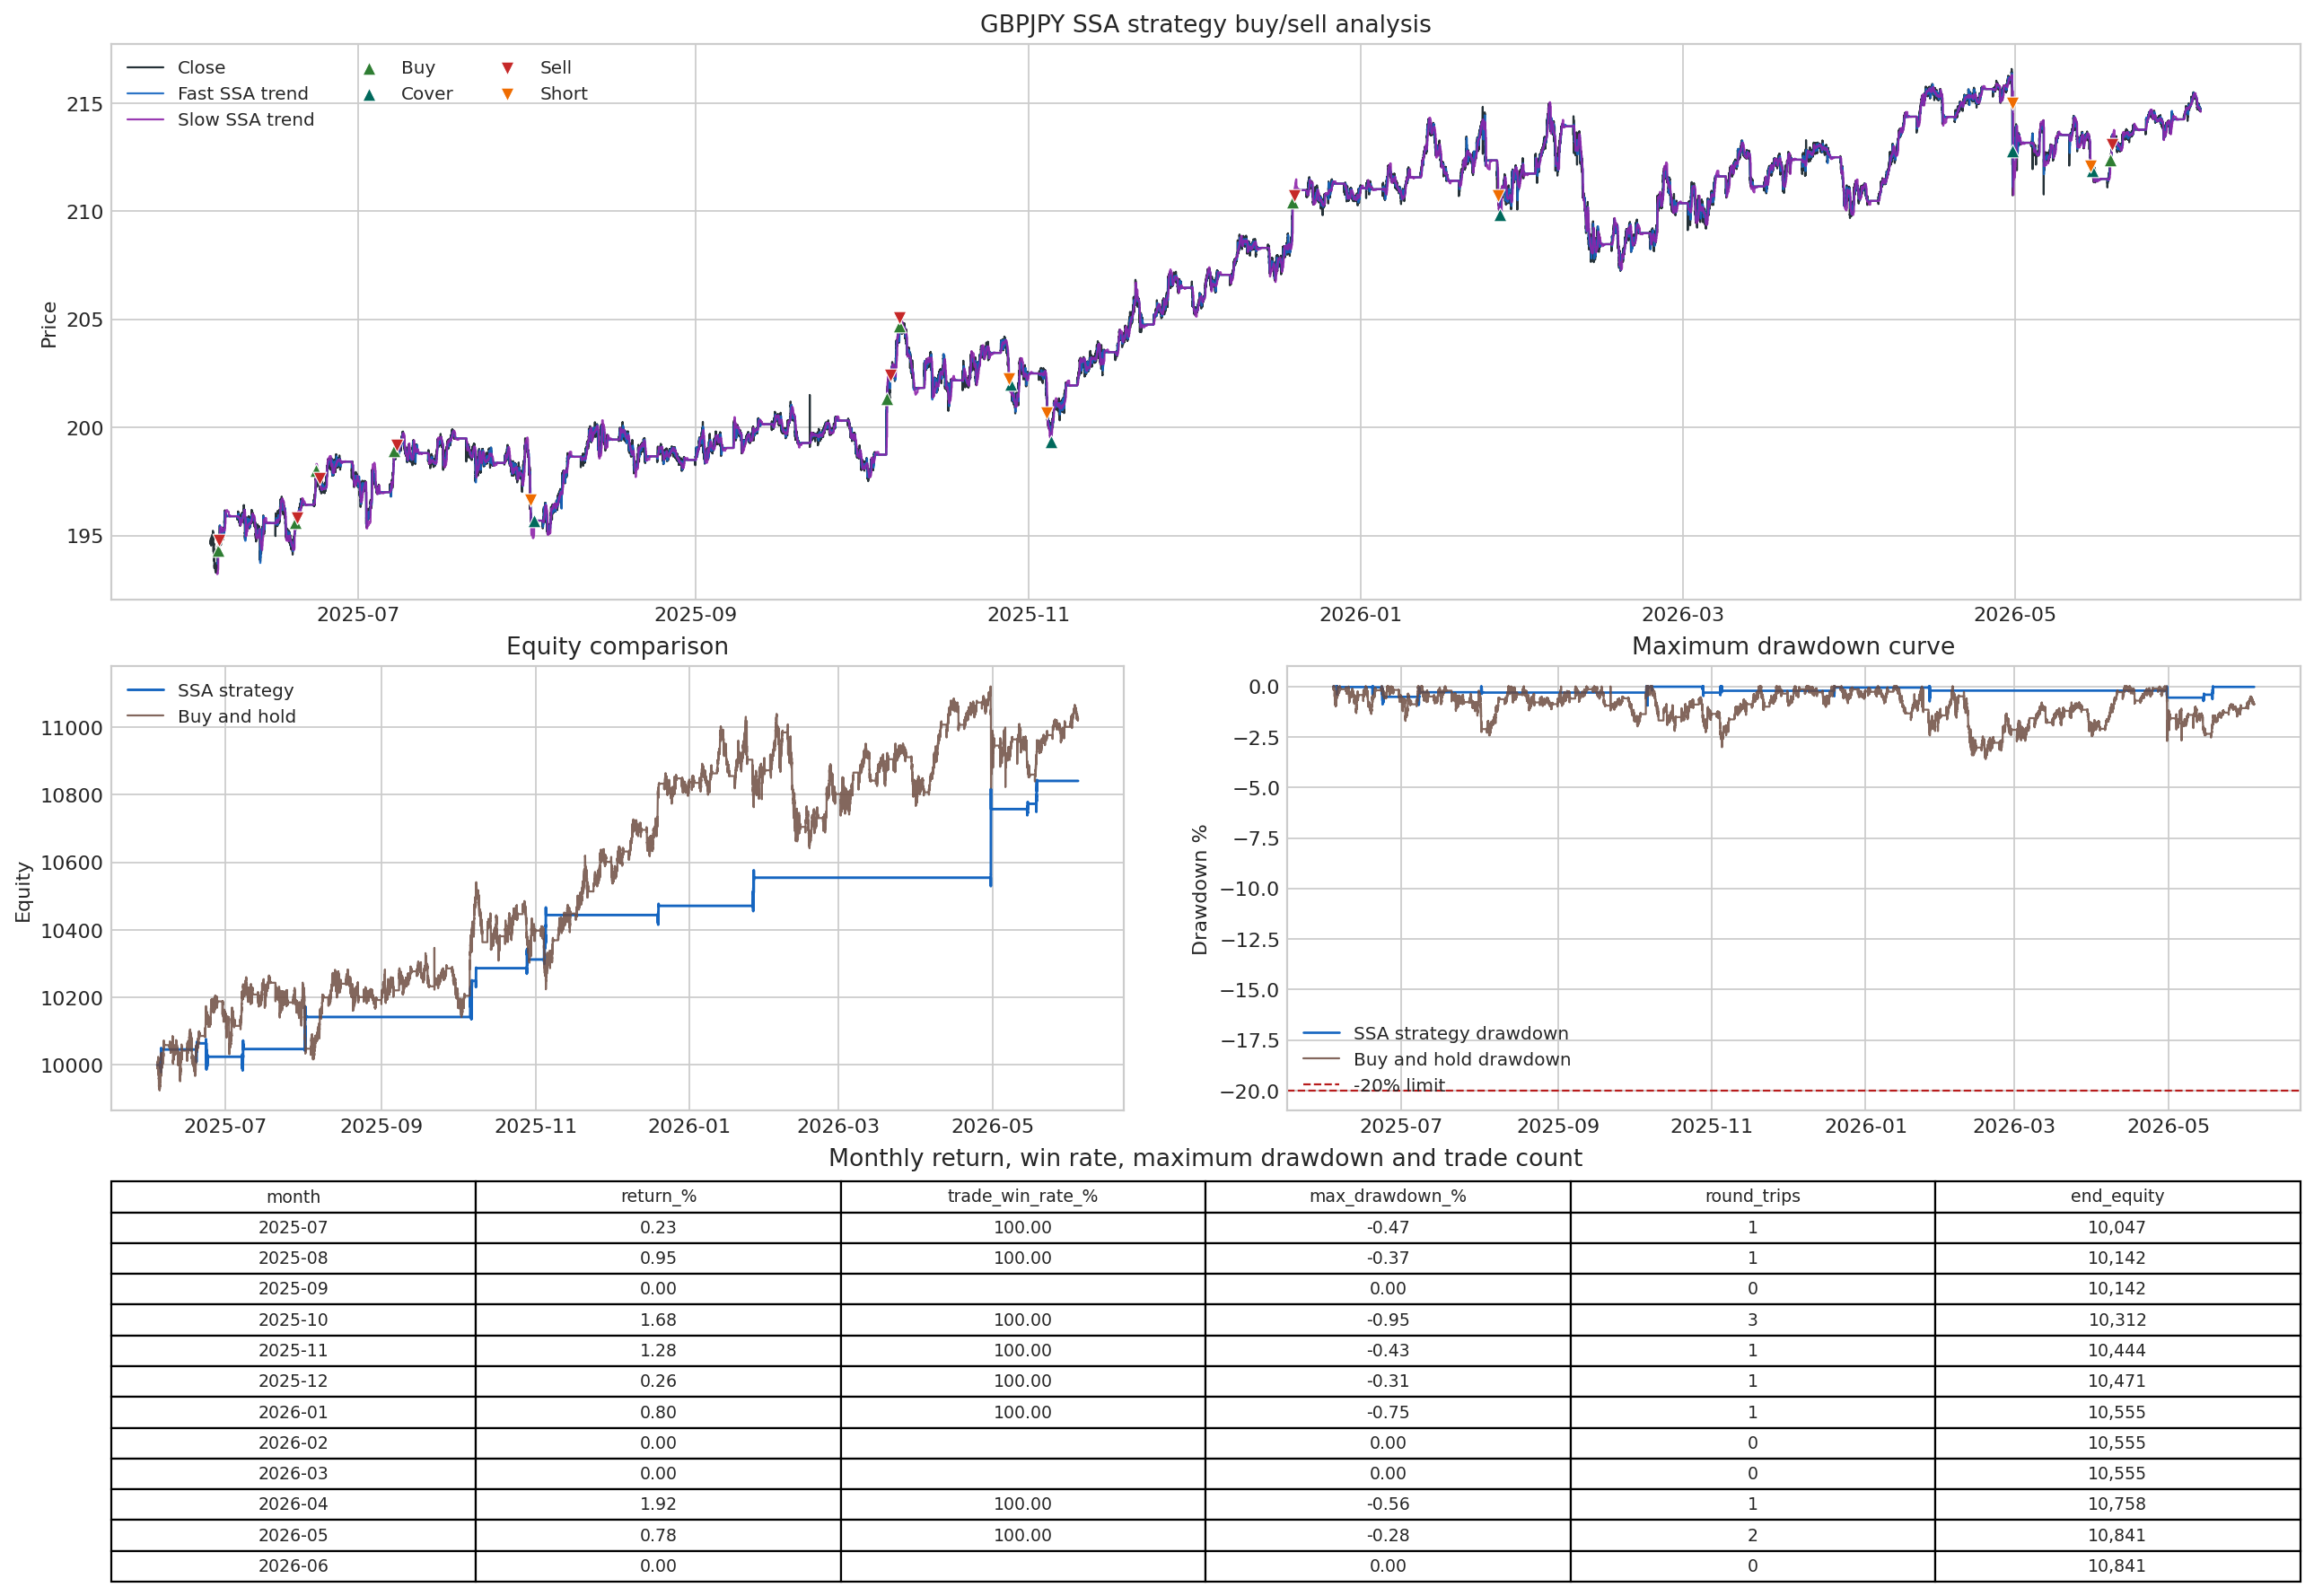

,month,return_%,trade_win_rate_%,max_drawdown_%,round_trips,end_equity
1,2025-07,0.23,100.0,-0.47,1,10047.05
2,2025-08,0.95,100.0,-0.37,1,10142.01
3,2025-09,0.00,NaN,0.00,0,10142.01
4,2025-10,1.68,100.0,-0.95,3,10312.29
5,2025-11,1.28,100.0,-0.43,1,10443.95
6,2025-12,0.26,100.0,-0.31,1,10471.15
7,2026-01,0.80,100.0,-0.75,1,10554.60
8,2026-02,0.00,NaN,0.00,0,10554.60
9,2026-03,0.00,NaN,0.00,0,10554.60
10,2026-04,1.92,100.0,-0.56,1,10757.65


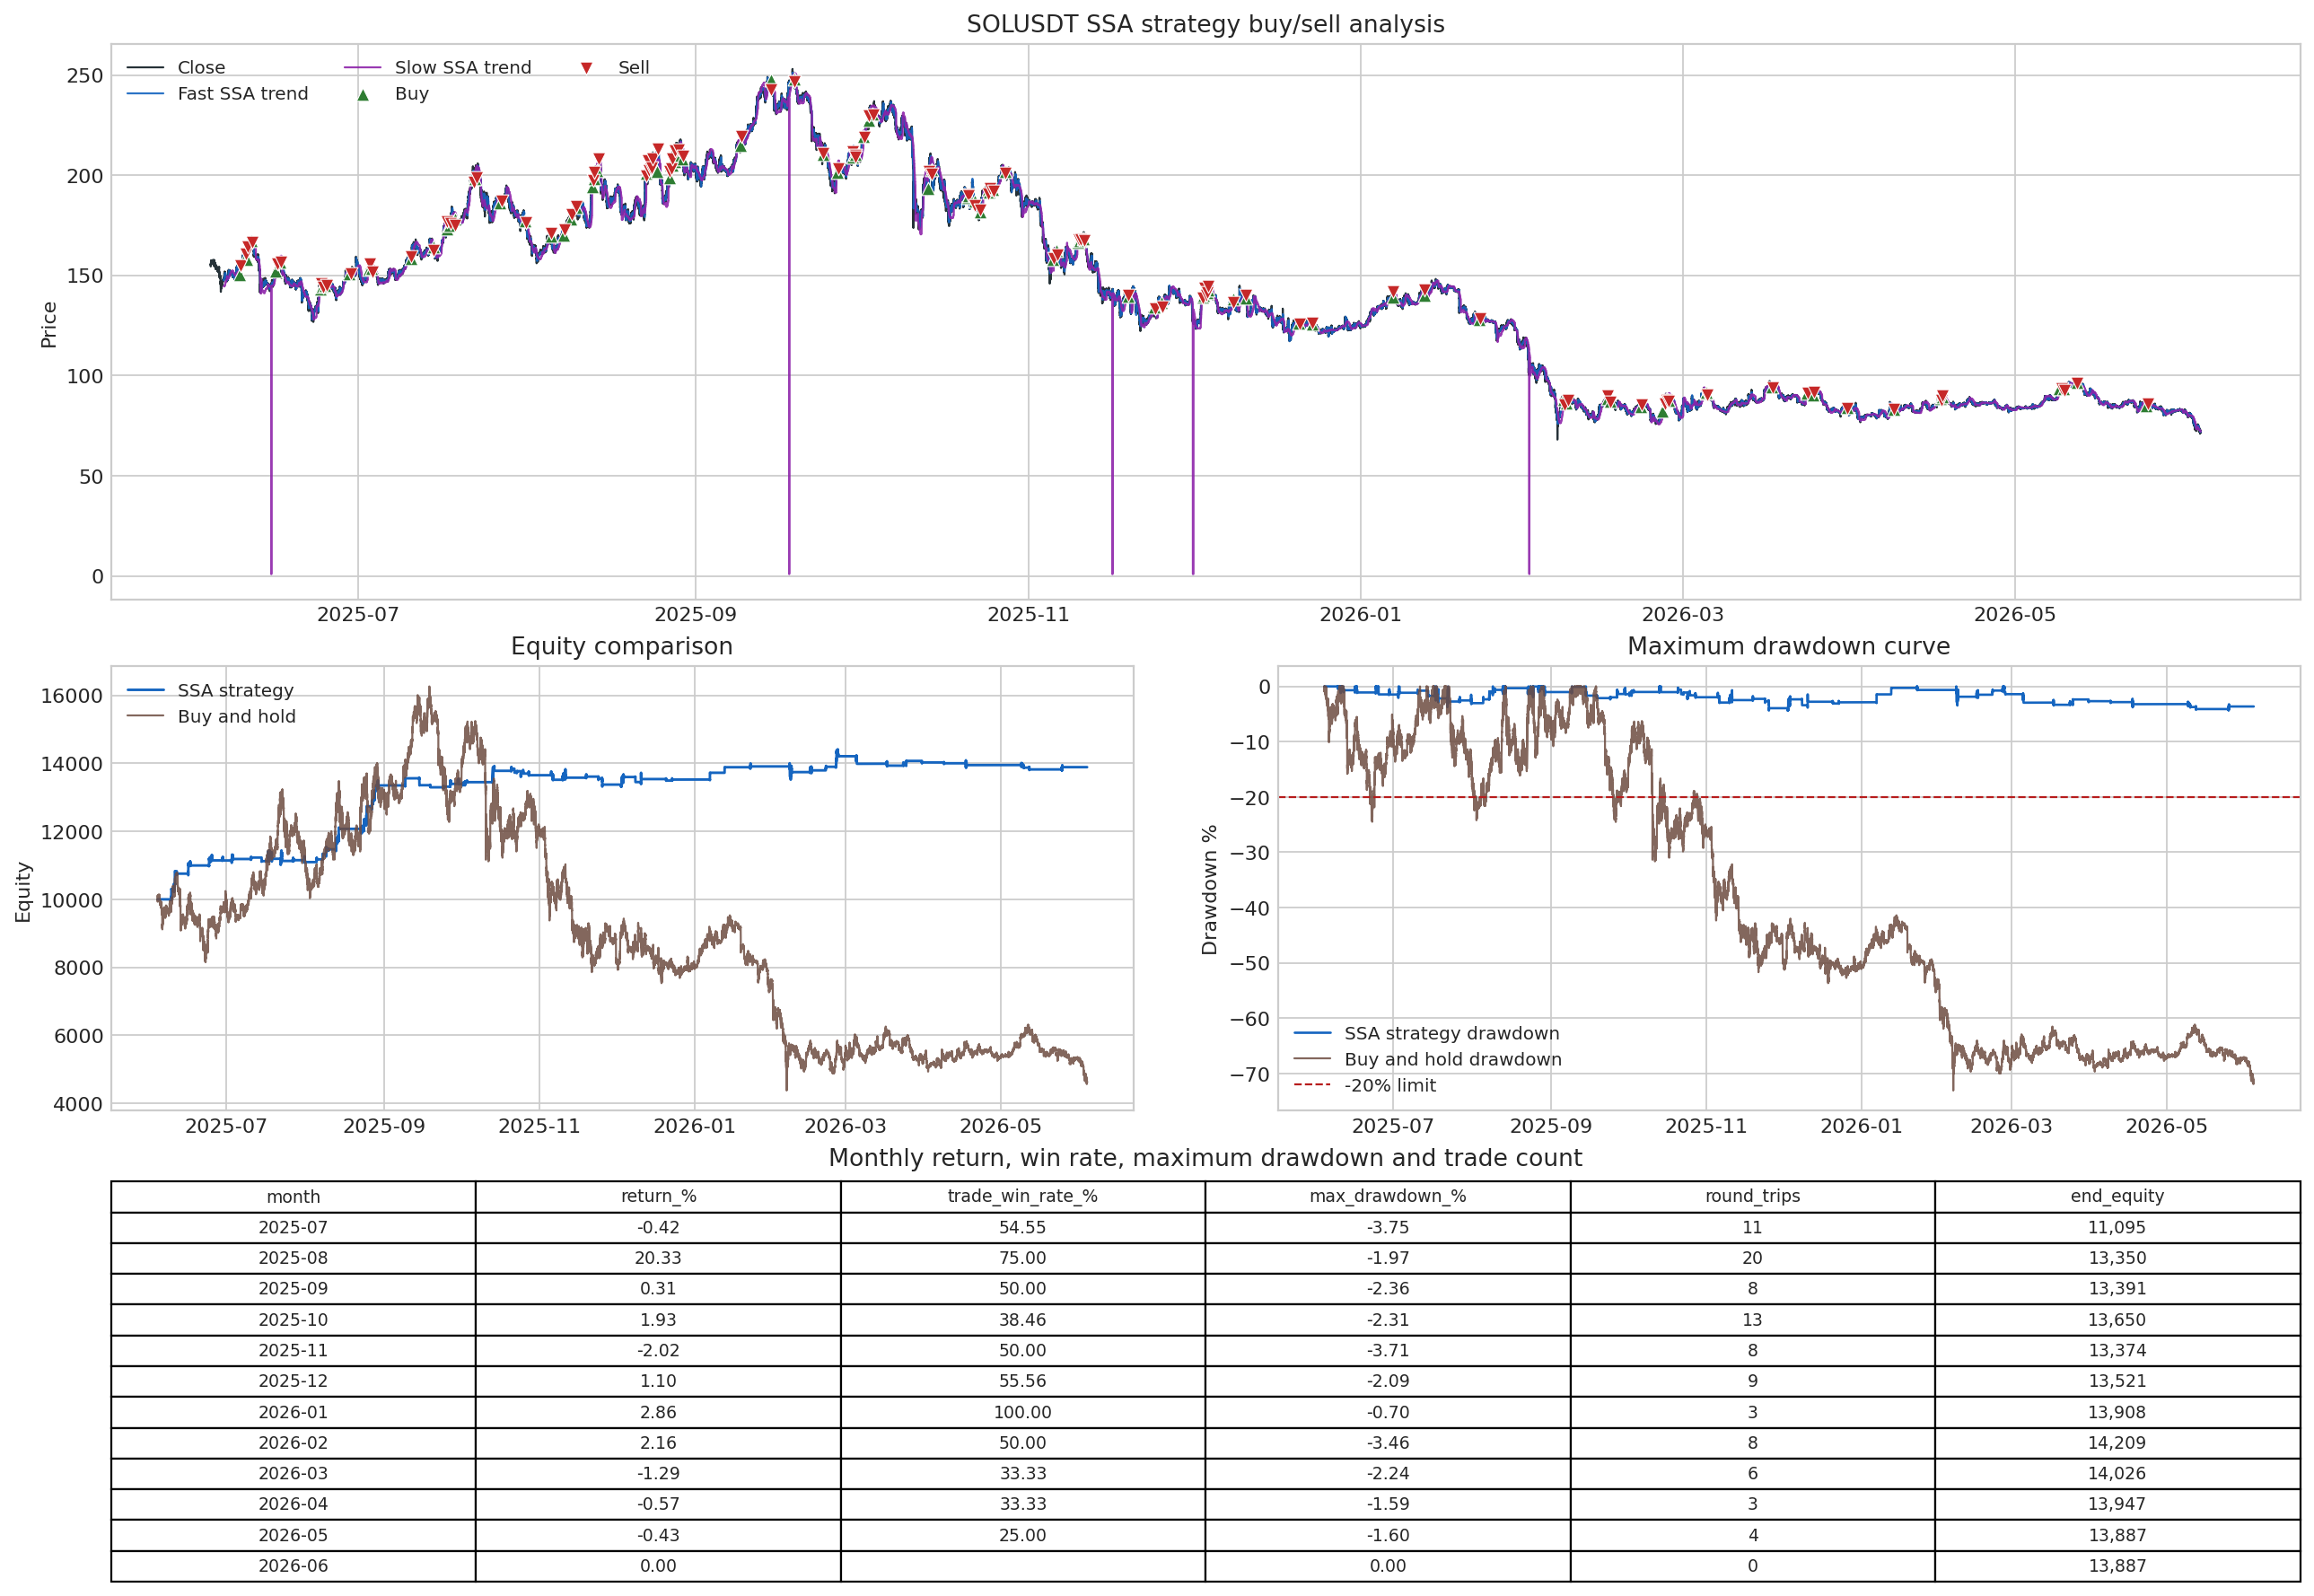

,month,return_%,trade_win_rate_%,max_drawdown_%,round_trips,end_equity
1,2025-07,-0.42,54.55,-3.75,11,11094.57
2,2025-08,20.33,75.00,-1.97,20,13349.87
3,2025-09,0.31,50.00,-2.36,8,13391.11
4,2025-10,1.93,38.46,-2.31,13,13649.72
5,2025-11,-2.02,50.00,-3.71,8,13373.74
6,2025-12,1.10,55.56,-2.09,9,13521.16
7,2026-01,2.86,100.00,-0.70,3,13908.24
8,2026-02,2.16,50.00,-3.46,8,14209.12
9,2026-03,-1.29,33.33,-2.24,6,14026.24
10,2026-04,-0.57,33.33,-1.59,3,13946.79


In [11]:
monthly_tables = {}
for symbol, result in results.items():
    monthly_tables[symbol] = plot_ssa_strategy_dashboard(symbol, result["ohlcv"], result["features"], result)
    display(monthly_tables[symbol].tail(12).round(2))

## Reading the output

- The equity panel compares a fixed-notional **SSA strategy** account against simple buy-and-hold on the same close series.
- The drawdown panel is the running percentage drawdown from each curve's own high-water mark. The dashed line marks the 20% drawdown constraint.
- The monthly table is separate from the chart panels so it does not cover the equity curve.
- `round_trips` counts completed trades: one entry plus one exit is one round trip.
- The search table at the top records the full BlueBEAR replay. Re-running this notebook should be close, but exact values can differ if the data file, DeTime native backend, or dependency versions differ.